In [ ]:
# ============================================================
# CELL 1 — Mount Google Drive & Setup Paths
# ============================================================

import os
from google.colab import drive

# --- Mount Drive (only if not already mounted) ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("✅ Drive already mounted, skipping.")

# --- Define project root (everything lives here) ---
PROJECT_ROOT = '/content/drive/MyDrive/DL_Project'
DATASET_DIR  = os.path.join(PROJECT_ROOT, 'flickr8k')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'results')

# --- Create folders if they don't exist ---
for folder in [PROJECT_ROOT, DATASET_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"📁 PROJECT_ROOT : {PROJECT_ROOT}")
print(f"📁 DATASET_DIR  : {DATASET_DIR}")
print(f"📁 MODELS_DIR   : {MODELS_DIR}")
print(f"📁 RESULTS_DIR  : {RESULTS_DIR}")
print("\n✅ Cell 1 done.")

In [2]:
# ============================================================
# CELL 2 — Install Dependencies
# ============================================================

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

required = {
    'datasets'      : 'datasets',
    'transformers'  : 'transformers',
    'nltk'          : 'nltk',
    'Pillow'        : 'PIL',
}

for pkg_name, import_name in required.items():
    try:
        __import__(import_name)
        print(f"✅ {pkg_name} already installed, skipping.")
    except ImportError:
        print(f"⬇️  Installing {pkg_name}...")
        install(pkg_name)
        print(f"✅ {pkg_name} installed.")

# --- NLTK data for BLEU score (download once) ---
import nltk
import os
import torch

nltk_data_path = os.path.join(PROJECT_ROOT, 'nltk_data')
os.makedirs(nltk_data_path, exist_ok=True)
nltk.data.path.append(nltk_data_path)

if not os.path.exists(os.path.join(nltk_data_path, 'tokenizers/punkt')):
    nltk.download('punkt', download_dir=nltk_data_path, quiet=True)
    print("✅ NLTK punkt downloaded.")
else:
    print("✅ NLTK punkt already exists, skipping.")

print("\n✅ Cell 2 done.")

✅ datasets already installed, skipping.
✅ transformers already installed, skipping.
✅ nltk already installed, skipping.
✅ Pillow already installed, skipping.
✅ NLTK punkt already exists, skipping.

✅ Cell 2 done.


In [3]:
# ============================================================
# CELL 3 — Download Flickr8k Dataset (Once)
# ============================================================

import os

IMAGES_DIR   = os.path.join(DATASET_DIR, 'Images')
CAPTIONS_FILE = os.path.join(DATASET_DIR, 'captions.txt')

# --- Check if dataset already exists ---
if os.path.exists(IMAGES_DIR) and os.path.exists(CAPTIONS_FILE):
    n_images = len(os.listdir(IMAGES_DIR))
    print(f"✅ Dataset already exists ({n_images} images), skipping download.")
else:
    print("⬇️  Downloading Flickr8k from Kaggle...")

    # --- Kaggle credentials ---
    os.environ['KAGGLE_USERNAME'] = 'zahrarezaei1375'
    os.environ['KAGGLE_KEY']      = 'KGAT_59ba1b8d49931899c72b3872a50c0425'

    os.makedirs(IMAGES_DIR, exist_ok=True)

    # Download & unzip into DATASET_DIR
    os.system(f'pip install kaggle -q')
    os.system(f'kaggle datasets download -d adityajn105/flickr8k -p {DATASET_DIR} --unzip')

    print(f"✅ Download complete.")
    n_images = len(os.listdir(IMAGES_DIR))
    print(f"📸 {n_images} images found.")

print(f"📄 Captions file: {CAPTIONS_FILE}")
print("\n✅ Cell 3 done.")

✅ Dataset already exists (8091 images), skipping download.
📄 Captions file: /content/drive/MyDrive/DL_Project/flickr8k/captions.txt

✅ Cell 3 done.


✅ Captions loaded: 40455 rows
📋 Columns: ['image', 'caption']

--- Sample rows ---
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  

📸 Unique images  : 8091
💬 Total captions : 40455
📊 Captions/image : 5.0

--- Verifying 3 random images ---


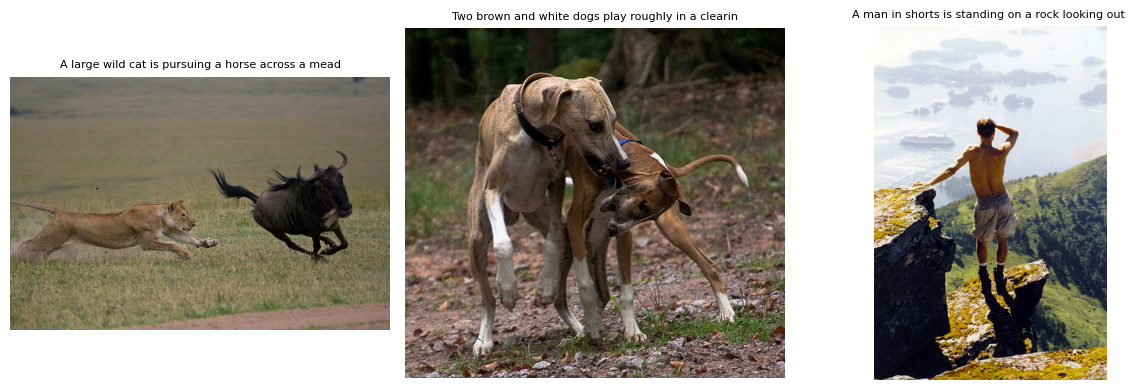


✅ Cell 4 done.


In [4]:
# ============================================================
# CELL 4 — Load & Verify Dataset
# ============================================================

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

# --- Load captions ---
df = pd.read_csv(CAPTIONS_FILE)
print(f"✅ Captions loaded: {len(df)} rows")
print(f"📋 Columns: {list(df.columns)}")
print(f"\n--- Sample rows ---")
print(df.head())

# --- Basic stats ---
n_images   = df['image'].nunique()
n_captions = len(df)
print(f"\n📸 Unique images  : {n_images}")
print(f"💬 Total captions : {n_captions}")
print(f"📊 Captions/image : {n_captions / n_images:.1f}")

# --- Verify a few images are readable ---
print(f"\n--- Verifying 3 random images ---")
sample = df['image'].sample(3, random_state=42).tolist()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img_name in zip(axes, sample):
    img_path = os.path.join(IMAGES_DIR, img_name)
    img      = Image.open(img_path).convert('RGB')
    caption  = df[df['image'] == img_name]['caption'].iloc[0]
    ax.imshow(img)
    ax.set_title(caption[:50], fontsize=8, wrap=True)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'))
plt.show()
print("\n✅ Cell 4 done.")

In [5]:
# ============================================================
# CELL 5 — Data Preprocessing & Vocabulary
# ============================================================

import os
import re
import json
import pickle
from collections import Counter

import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# --------------------------------------------------------
# Load captions
# --------------------------------------------------------
df = pd.read_csv(CAPTIONS_FILE)

VOCAB_FILE = os.path.join(DATASET_DIR, 'vocab.pkl')

# --------------------------------------------------------
# Clean caption text
# --------------------------------------------------------
def clean_caption(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

df['caption'] = df['caption'].apply(clean_caption)

# --------------------------------------------------------
# Build vocabulary (only if not already saved)
# --------------------------------------------------------
if os.path.exists(VOCAB_FILE):
    with open(VOCAB_FILE, 'rb') as f:
        vocab = pickle.load(f)
    print(f"✅ Vocabulary loaded from cache ({len(vocab)} tokens).")
else:
    print("Building vocabulary...")

    MIN_FREQ = 5  # ignore words appearing less than 5 times

    counter = Counter()
    for caption in df['caption']:
        counter.update(caption.split())

    special_tokens = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
    words = [w for w, c in counter.items() if c >= MIN_FREQ]

    vocab = {token: idx for idx, token in enumerate(special_tokens + sorted(words))}

    with open(VOCAB_FILE, 'wb') as f:
        pickle.dump(vocab, f)

    print(f"✅ Vocabulary built and saved ({len(vocab)} tokens).")

idx2word = {idx: word for word, idx in vocab.items()}

PAD_IDX = vocab['<PAD>']
SOS_IDX = vocab['<SOS>']
EOS_IDX = vocab['<EOS>']
UNK_IDX = vocab['<UNK>']

print(f"   PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}, UNK={UNK_IDX}")
print(f"\n✅ Cell 5 done.")

✅ Vocabulary loaded from cache (2995 tokens).
   PAD=0, SOS=1, EOS=2, UNK=3

✅ Cell 5 done.


In [6]:
# ============================================================
# CELL 5.5 — Copy dataset images to Colab local storage
# (much faster than reading from Google Drive each batch)
# ============================================================

import shutil
import os

LOCAL_IMAGES_DIR = '/content/flickr8k_images'

if os.path.exists(LOCAL_IMAGES_DIR) and len(os.listdir(LOCAL_IMAGES_DIR)) > 8000:
    print(f"✅ Images already in local storage ({len(os.listdir(LOCAL_IMAGES_DIR))} files), skipping.")
else:
    print("Copying images from Drive to local storage...")
    os.makedirs(LOCAL_IMAGES_DIR, exist_ok=True)
    shutil.copytree(IMAGES_DIR, LOCAL_IMAGES_DIR, dirs_exist_ok=True)
    print(f"✅ Done. {len(os.listdir(LOCAL_IMAGES_DIR))} images copied.")

# Update IMAGES_DIR to point to local copy
IMAGES_DIR = LOCAL_IMAGES_DIR
print(f"IMAGES_DIR → {IMAGES_DIR}")
print(f"\n✅ Cell 5.5 done.")

Copying images from Drive to local storage...
✅ Done. 8091 images copied.
IMAGES_DIR → /content/flickr8k_images

✅ Cell 5.5 done.


In [7]:
# ============================================================
# CELL 6 — Dataset Class & DataLoaders
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
import os

# --------------------------------------------------------
# Image transforms
# --------------------------------------------------------
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --------------------------------------------------------
# Dataset class
# --------------------------------------------------------
class Flickr8kDataset(Dataset):
    def __init__(self, df, images_dir, vocab, transform=None):
        self.df         = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.vocab      = vocab
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img     = Image.open(os.path.join(self.images_dir, row['image'])).convert('RGB')

        if self.transform:
            img = self.transform(img)

        tokens  = row['caption'].split()
        caption = ([SOS_IDX]
                   + [self.vocab.get(w, UNK_IDX) for w in tokens]
                   + [EOS_IDX])
        caption = torch.tensor(caption, dtype=torch.long)

        return img, caption

# --------------------------------------------------------
# Collate function — pads captions to same length in batch
# --------------------------------------------------------
def collate_fn(batch):
    imgs, captions = zip(*batch)
    imgs     = torch.stack(imgs, dim=0)
    captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
    return imgs, captions

# --------------------------------------------------------
# Train / val split (90% / 10%)
# --------------------------------------------------------
unique_imgs = df['image'].unique()

n_train    = int(0.9 * len(unique_imgs))
train_imgs = set(unique_imgs[:n_train])
val_imgs   = set(unique_imgs[n_train:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train samples : {len(train_df)}")
print(f"Val   samples : {len(val_df)}")

# --------------------------------------------------------
# DataLoaders — num_workers=0 for Colab stability
# --------------------------------------------------------
BATCH_SIZE = 32

train_dataset = Flickr8kDataset(train_df, IMAGES_DIR, vocab, train_transform)
val_dataset   = Flickr8kDataset(val_df,   IMAGES_DIR, vocab, val_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"\n✅ Cell 6 done.")

Train samples : 36405
Val   samples : 4050
Train batches : 1138
Val   batches : 127

✅ Cell 6 done.


In [14]:
# ============================================================
# CELL 7 — Model Architecture (Spatial Cross-Attention)
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models
import math

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

VOCAB_SIZE = len(vocab)
EMBED_DIM  = 256
NUM_HEADS  = 8
FF_DIM     = 512
NUM_LAYERS = 2
DROPOUT    = 0.3
MAX_LEN    = 50

# --------------------------------------------------------
# FFT Decomposition
# --------------------------------------------------------
def fft_decompose(images, cutoff=20):
    B, C, H, W = images.shape
    fft        = torch.fft.fft2(images)
    fft_sh     = torch.fft.fftshift(fft)

    cy, cx     = H // 2, W // 2
    ys         = torch.arange(H, device=images.device).float() - cy
    xs         = torch.arange(W, device=images.device).float() - cx
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    mask_low   = ((grid_y**2 + grid_x**2).sqrt() <= cutoff).float()
    mask_low   = mask_low.unsqueeze(0).unsqueeze(0)
    mask_high  = 1.0 - mask_low

    fft_low    = fft_sh * mask_low
    fft_high   = fft_sh * mask_high

    low  = torch.fft.ifft2(torch.fft.ifftshift(fft_low)).real
    high = torch.fft.ifft2(torch.fft.ifftshift(fft_high)).real

    return low, high

# --------------------------------------------------------
# Spatial CNN Encoder — returns feature map, not vector
# --------------------------------------------------------
class SpatialCNNEncoder(nn.Module):
    """
    ResNet-18 encoder that returns spatial feature map (B, 49, embed_dim)
    instead of a single vector. Allows cross-attention over image regions.
    """
    def __init__(self, embed_dim, pretrained=True):
        super().__init__()
        resnet        = models.resnet18(weights='DEFAULT' if pretrained else None)
        # Remove avgpool and fc — keep spatial feature map (7x7)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.project  = nn.Linear(512, embed_dim)
        self.norm     = nn.LayerNorm(embed_dim)

    def forward(self, x):
        feats = self.backbone(x)              # (B, 512, 7, 7)
        B, C, H, W = feats.shape
        feats = feats.permute(0, 2, 3, 1)    # (B, 7, 7, 512)
        feats = feats.reshape(B, H*W, C)     # (B, 49, 512)
        feats = self.project(feats)           # (B, 49, embed_dim)
        feats = self.norm(feats)
        return feats                          # (B, 49, embed_dim)

# --------------------------------------------------------
# Positional Encoding
# --------------------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, dropout, max_len=200):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe           = torch.zeros(max_len, embed_dim)
        pos          = torch.arange(max_len).unsqueeze(1).float()
        div          = torch.exp(torch.arange(0, embed_dim, 2).float()
                                 * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# --------------------------------------------------------
# Baseline Model — spatial ResNet + Transformer decoder
# --------------------------------------------------------
class BaselineCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder   = SpatialCNNEncoder(EMBED_DIM, pretrained=True)
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(EMBED_DIM, DROPOUT)
        decoder_layer  = nn.TransformerDecoderLayer(EMBED_DIM, NUM_HEADS,
                                                    FF_DIM, DROPOUT,
                                                    batch_first=True)
        self.decoder   = nn.TransformerDecoder(decoder_layer, NUM_LAYERS)
        self.fc_out    = nn.Linear(EMBED_DIM, VOCAB_SIZE)

    def forward(self, images, captions):
        # Memory: (B, 49, EMBED_DIM) — 49 spatial regions
        memory   = self.encoder(images)

        tgt      = self.pos_enc(self.embedding(captions))
        tgt_len  = captions.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
                       tgt_len, device=captions.device)
        pad_mask = (captions == PAD_IDX)

        out      = self.decoder(tgt, memory,
                                tgt_mask=tgt_mask,
                                tgt_key_padding_mask=pad_mask)
        return self.fc_out(out)

# --------------------------------------------------------
# FreqAware Model — dual spatial branches + Transformer decoder
# --------------------------------------------------------
class FreqAwareCaptioner(nn.Module):
    def __init__(self, cutoff=20):
        super().__init__()
        self.cutoff   = cutoff
        self.enc_low  = SpatialCNNEncoder(EMBED_DIM, pretrained=True)
        self.enc_high = SpatialCNNEncoder(EMBED_DIM, pretrained=False)

        # Fusion: project concatenated spatial features back to embed_dim
        self.fusion   = nn.Sequential(
            nn.Linear(EMBED_DIM * 2, EMBED_DIM),
            nn.ReLU(),
            nn.LayerNorm(EMBED_DIM)
        )

        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(EMBED_DIM, DROPOUT)
        decoder_layer  = nn.TransformerDecoderLayer(EMBED_DIM, NUM_HEADS,
                                                    FF_DIM, DROPOUT,
                                                    batch_first=True)
        self.decoder   = nn.TransformerDecoder(decoder_layer, NUM_LAYERS)
        self.fc_out    = nn.Linear(EMBED_DIM, VOCAB_SIZE)

    def forward(self, images, captions):
        low, high  = fft_decompose(images, cutoff=self.cutoff)

        # Each branch: (B, 49, EMBED_DIM)
        feat_low   = self.enc_low(low)
        feat_high  = self.enc_high(high)

        # Fuse spatial features: (B, 49, EMBED_DIM*2) → (B, 49, EMBED_DIM)
        memory     = self.fusion(torch.cat([feat_low, feat_high], dim=-1))

        tgt        = self.pos_enc(self.embedding(captions))
        tgt_len    = captions.size(1)
        tgt_mask   = nn.Transformer.generate_square_subsequent_mask(
                         tgt_len, device=captions.device)
        pad_mask   = (captions == PAD_IDX)

        out        = self.decoder(tgt, memory,
                                  tgt_mask=tgt_mask,
                                  tgt_key_padding_mask=pad_mask)
        return self.fc_out(out)

# --------------------------------------------------------
# Sanity check
# --------------------------------------------------------
baseline_model  = BaselineCaptioner().to(DEVICE)
freqaware_model = FreqAwareCaptioner(cutoff=20).to(DEVICE)

dummy_imgs = torch.randn(2, 3, 224, 224).to(DEVICE)
dummy_caps = torch.randint(0, VOCAB_SIZE, (2, 10)).to(DEVICE)

out_b = baseline_model(dummy_imgs, dummy_caps)
out_f = freqaware_model(dummy_imgs, dummy_caps)

print(f"Baseline  output shape : {out_b.shape}")
print(f"FreqAware output shape : {out_f.shape}")

n_params_b = sum(p.numel() for p in baseline_model.parameters()  if p.requires_grad)
n_params_f = sum(p.numel() for p in freqaware_model.parameters() if p.requires_grad)
print(f"\nBaseline  params : {n_params_b:,}")
print(f"FreqAware params : {n_params_f:,}")
print(f"\n✅ Cell 7 done.")

Device: cuda
Baseline  output shape : torch.Size([2, 10, 2995])
FreqAware output shape : torch.Size([2, 10, 2995])

Baseline  params : 14,426,355
FreqAware params : 25,866,547

✅ Cell 7 done.


In [15]:
import os, shutil

# Backup old checkpoints
for name in ['baseline', 'freqaware']:
    old = os.path.join(MODELS_DIR, f'{name}_best.pth')
    new = os.path.join(MODELS_DIR, f'{name}_v1_best.pth')
    if os.path.exists(old):
        shutil.move(old, new)
        print(f"✅ Moved {name}_best.pth → {name}_v1_best.pth")

# Backup old histories
for name in ['baseline', 'freqaware']:
    old = os.path.join(RESULTS_DIR, f'{name}_history.json')
    new = os.path.join(RESULTS_DIR, f'{name}_v1_history.json')
    if os.path.exists(old):
        shutil.move(old, new)
        print(f"✅ Moved {name}_history.json → {name}_v1_history.json")

✅ Moved baseline_best.pth → baseline_v1_best.pth
✅ Moved freqaware_best.pth → freqaware_v1_best.pth
✅ Moved baseline_history.json → baseline_v1_history.json
✅ Moved freqaware_history.json → freqaware_v1_history.json


In [16]:
# ============================================================
# CELL 8 — Train or Load Models
# ============================================================

import torch
import torch.nn as nn
import time
import json
import os

# --------------------------------------------------------
# Training config
# --------------------------------------------------------
NUM_EPOCHS    = 10
LEARNING_RATE = 3e-4
CLIP_GRAD     = 1.0

# --------------------------------------------------------
# Train one epoch
# --------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for imgs, captions in loader:
        imgs     = imgs.to(device)
        captions = captions.to(device)

        inp = captions[:, :-1]
        tgt = captions[:, 1:]

        optimizer.zero_grad()
        output = model(imgs, inp)
        output = output.reshape(-1, output.size(-1))
        tgt    = tgt.reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# --------------------------------------------------------
# Validate one epoch
# --------------------------------------------------------
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for imgs, captions in loader:
            imgs     = imgs.to(device)
            captions = captions.to(device)

            inp = captions[:, :-1]
            tgt = captions[:, 1:]

            output = model(imgs, inp)
            output = output.reshape(-1, output.size(-1))
            tgt    = tgt.reshape(-1)

            loss   = criterion(output, tgt)
            total_loss += loss.item()

    return total_loss / len(loader)

# --------------------------------------------------------
# Full training function with checkpointing
# --------------------------------------------------------
def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    checkpoint_path = os.path.join(MODELS_DIR, f'{model_name}_best.pth')
    history_path    = os.path.join(RESULTS_DIR, f'{model_name}_history.json')

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    start_epoch = 0
    best_val    = float('inf')
    history     = {'train_loss': [], 'val_loss': []}

    # Load checkpoint if exists
    if os.path.exists(checkpoint_path) and os.path.exists(history_path):
        with open(history_path) as f:
            saved_history = json.load(f)

        # Only skip training if all epochs are already done
        if len(saved_history['train_loss']) >= num_epochs:
            model.load_state_dict(
                torch.load(checkpoint_path, map_location=DEVICE)['model_state']
            )
            model.eval()
            ckpt = torch.load(checkpoint_path, map_location=DEVICE)
            print(f"✅ {model_name} already trained — loaded best checkpoint "
                  f"(epoch {ckpt['epoch']+1}, val: {ckpt['best_val']:.4f})")
            return model, saved_history

        # Resume from last saved checkpoint
        ckpt        = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        start_epoch = len(saved_history['train_loss'])
        best_val    = ckpt['best_val']
        history     = saved_history
        print(f"Resuming {model_name} from epoch {start_epoch+1} "
              f"(best val: {best_val:.4f})")

    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    for epoch in range(start_epoch, num_epochs):
        t0         = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss   = val_epoch(model,   val_loader,   criterion,            DEVICE)
        scheduler.step()

        elapsed = time.time() - t0
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"train_loss: {train_loss:.4f}  "
              f"val_loss: {val_loss:.4f}  "
              f"time: {elapsed:.1f}s")

        if val_loss < best_val:
            best_val = val_loss
            torch.save({
                'epoch':           epoch,
                'model_state':     model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val':        best_val,
            }, checkpoint_path)
            print(f"  → Saved best checkpoint (val: {best_val:.4f})")

        with open(history_path, 'w') as f:
            json.dump(history, f)

    print(f"\n✅ {model_name} training done. Best val loss: {best_val:.4f}")
    return model, history

# --------------------------------------------------------
# Train or load both models
# --------------------------------------------------------
baseline_model,  history_baseline  = train_model(baseline_model,  'baseline')
freqaware_model, history_freqaware = train_model(freqaware_model, 'freqaware')

print("\n✅ Cell 8 done.")


Training: baseline
Epoch [01/10] train_loss: 3.9547  val_loss: 3.3675  time: 299.8s
  → Saved best checkpoint (val: 3.3675)
Epoch [02/10] train_loss: 3.2583  val_loss: 3.1084  time: 292.9s
  → Saved best checkpoint (val: 3.1084)
Epoch [03/10] train_loss: 2.9882  val_loss: 3.0314  time: 297.6s
  → Saved best checkpoint (val: 3.0314)
Epoch [04/10] train_loss: 2.8086  val_loss: 2.9606  time: 300.2s
  → Saved best checkpoint (val: 2.9606)
Epoch [05/10] train_loss: 2.6115  val_loss: 2.9283  time: 300.2s
  → Saved best checkpoint (val: 2.9283)
Epoch [06/10] train_loss: 2.5157  val_loss: 2.9236  time: 305.2s
  → Saved best checkpoint (val: 2.9236)
Epoch [07/10] train_loss: 2.4387  val_loss: 2.9323  time: 300.8s
Epoch [08/10] train_loss: 2.3741  val_loss: 2.9538  time: 303.7s
Epoch [09/10] train_loss: 2.2676  val_loss: 2.9547  time: 305.6s
Epoch [10/10] train_loss: 2.2203  val_loss: 2.9830  time: 304.3s

✅ baseline training done. Best val loss: 2.9236

Training: freqaware
Epoch [01/10] train_

In [36]:
# ============================================================
# CELL 8.5 — Beam Search Caption Generation
# ============================================================

import torch

def generate_caption(model, image, max_len=MAX_LEN, beam_size=5):
    """
    Beam search caption generation.
    Args:
        model     : captioning model
        image     : (C, H, W) tensor
        max_len   : maximum caption length
        beam_size : number of beams
    Returns:
        list of words
    """
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(DEVICE)   # (1, C, H, W)

        # Each beam: (tokens, log_prob)
        beams = [([SOS_IDX], 0.0)]
        completed = []

        for _ in range(max_len):
            new_beams = []

            for tokens, log_prob in beams:
                if tokens[-1] == EOS_IDX:
                    completed.append((tokens, log_prob))
                    continue

                tgt    = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
                output = model(image, tgt)                   # (1, seq_len, vocab_size)
                logits = output[0, -1]                       # (vocab_size,)
                log_probs = torch.log_softmax(logits, dim=-1)

                # Take top beam_size tokens
                topk_log_probs, topk_tokens = log_probs.topk(beam_size)

                for i in range(beam_size):
                    new_token    = topk_tokens[i].item()
                    new_log_prob = log_prob + topk_log_probs[i].item()
                    new_beams.append((tokens + [new_token], new_log_prob))

            if not new_beams:
                break

            # Keep top beam_size beams (normalize by length)
            new_beams.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            beams = new_beams[:beam_size]

            # Stop if all beams completed
            if all(t[-1] == EOS_IDX for t, _ in beams):
                completed.extend(beams)
                break

        # Pick best completed beam
        if completed:
            best_tokens = max(completed,
                              key=lambda x: x[1] / len(x[0]))[0]
        else:
            best_tokens = max(beams,
                              key=lambda x: x[1] / len(x[0]))[0]

    words = [idx2word.get(t, '<UNK>') for t in best_tokens[1:]
             if t not in [EOS_IDX, PAD_IDX, SOS_IDX]]
    return words

print("✅ Beam search (beam_size=5) ready.")
print("✅ Cell 8.5 done.")

✅ Beam search (beam_size=5) ready.
✅ Cell 8.5 done.


✅ Loaded freqaware (epoch 9, val: 2.9699)
  Cutoff     BLEU-4
--------------------
       5     0.0635
      10     0.0969
      20     0.1761
      30     0.1616
      40     0.1666
      56     0.1628


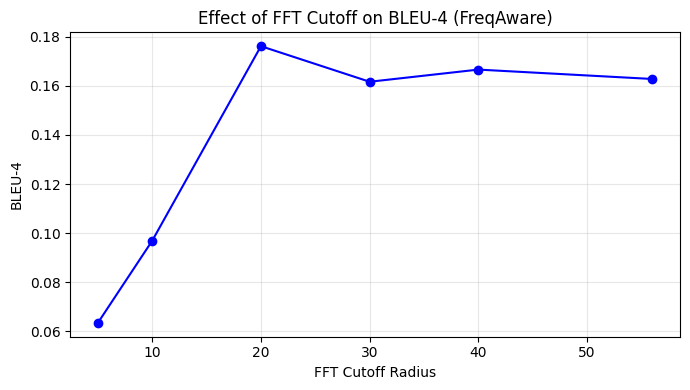


Best cutoff: 20

✅ Cell 9 done.


In [13]:
# ============================================================
# CELL 9 — FFT Cutoff Analysis
# ============================================================

import torch
import json
import os
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# --------------------------------------------------------
# Load best FreqAware checkpoint
# --------------------------------------------------------
checkpoint_path = os.path.join(MODELS_DIR, 'freqaware_best.pth')
ckpt = torch.load(checkpoint_path, map_location=DEVICE)
freqaware_model.load_state_dict(ckpt['model_state'])
freqaware_model.eval()
print(f"✅ Loaded freqaware (epoch {ckpt['epoch']+1}, val: {ckpt['best_val']:.4f})")

# --------------------------------------------------------
# Evaluate BLEU for a given cutoff value
# --------------------------------------------------------
def evaluate_cutoff(model, cutoff, val_df, images_dir, transform, n_samples=200):
    model.cutoff = cutoff

    refs_dict = {}
    for _, row in val_df.iterrows():
        img_name = row['image']
        tokens   = row['caption'].split()
        if img_name not in refs_dict:
            refs_dict[img_name] = []
        refs_dict[img_name].append(tokens)

    unique_val_imgs = list(refs_dict.keys())[:n_samples]
    hypotheses, references = [], []

    for img_name in unique_val_imgs:
        img_path = os.path.join(images_dir, img_name)
        img      = transform(Image.open(img_path).convert('RGB'))
        hyp      = generate_caption(model, img)
        hypotheses.append(hyp)
        references.append(refs_dict[img_name])

    smoother = SmoothingFunction().method1
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smoother)
    return bleu4

# --------------------------------------------------------
# Test multiple cutoff values
# --------------------------------------------------------
cutoffs = [5, 10, 20, 30, 40, 56]
results_cutoff = {}

print(f"{'Cutoff':>8} {'BLEU-4':>10}")
print("-" * 20)

for cutoff in cutoffs:
    bleu4 = evaluate_cutoff(freqaware_model, cutoff,
                            val_df, IMAGES_DIR, val_transform, n_samples=200)
    results_cutoff[cutoff] = bleu4
    print(f"{cutoff:>8} {bleu4:>10.4f}")

# --------------------------------------------------------
# Save results
# --------------------------------------------------------
with open(os.path.join(RESULTS_DIR, 'cutoff_analysis.json'), 'w') as f:
    json.dump(results_cutoff, f, indent=2)

# --------------------------------------------------------
# Plot
# --------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(list(results_cutoff.keys()),
         list(results_cutoff.values()),
         'b-o', markersize=6)
plt.xlabel('FFT Cutoff Radius')
plt.ylabel('BLEU-4')
plt.title('Effect of FFT Cutoff on BLEU-4 (FreqAware)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cutoff_analysis.png'), dpi=120)
plt.show()

print(f"\nBest cutoff: {max(results_cutoff, key=results_cutoff.get)}")
print(f"\n✅ Cell 9 done.")

In [38]:
# ============================================================
# CELL 10 — Evaluation & BLEU Score
# ============================================================

import torch
import json
import os
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --------------------------------------------------------
# Load best checkpoints
# --------------------------------------------------------
def load_best_model(model, model_name):
    checkpoint_path = os.path.join(MODELS_DIR, f'{model_name}_best.pth')
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f"✅ Loaded {model_name} (epoch {ckpt['epoch']+1}, val: {ckpt['best_val']:.4f})")
    return model

baseline_model  = load_best_model(baseline_model,  'baseline')
freqaware_model = load_best_model(freqaware_model, 'freqaware')

# --------------------------------------------------------
# Compute BLEU on validation set
# --------------------------------------------------------
def compute_bleu(model, val_df, images_dir, transform, n_samples=500):
    """
    Compute corpus BLEU-1,2,3,4 on n_samples from val set.
    """
    # Group references by image
    refs_dict = {}
    for _, row in val_df.iterrows():
        img_name = row['image']
        tokens   = row['caption'].split()
        if img_name not in refs_dict:
            refs_dict[img_name] = []
        refs_dict[img_name].append(tokens)

    unique_val_imgs = list(refs_dict.keys())[:n_samples]

    hypotheses = []
    references = []

    for img_name in unique_val_imgs:
        img_path = os.path.join(images_dir, img_name)
        img      = transform(Image.open(img_path).convert('RGB'))
        hyp      = generate_caption(model, img)
        hypotheses.append(hyp)
        references.append(refs_dict[img_name])

    smoother = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1,0,0,0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(0.5,0.5,0,0), smoothing_function=smoother)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(0.33,0.33,0.33,0), smoothing_function=smoother)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)
    return bleu1, bleu2, bleu3, bleu4

# --------------------------------------------------------
# Evaluate both models
# --------------------------------------------------------
from PIL import Image

print("Evaluating Baseline  (500 samples)...")
b1, b2, b3, b4 = compute_bleu(baseline_model, val_df, IMAGES_DIR, val_transform)
print(f"  BLEU-1: {b1:.4f}  BLEU-2: {b2:.4f}  BLEU-3: {b3:.4f}  BLEU-4: {b4:.4f}")

print("\nEvaluating FreqAware (500 samples)...")
f1, f2, f3, f4 = compute_bleu(freqaware_model, val_df, IMAGES_DIR, val_transform)
print(f"  BLEU-1: {f1:.4f}  BLEU-2: {f2:.4f}  BLEU-3: {f3:.4f}  BLEU-4: {f4:.4f}")

# --------------------------------------------------------
# Save results
# --------------------------------------------------------
results = {
    'baseline':  {'bleu1': b1, 'bleu2': b2, 'bleu3': b3, 'bleu4': b4},
    'freqaware': {'bleu1': f1, 'bleu2': f2, 'bleu3': f3, 'bleu4': f4},
}
with open(os.path.join(RESULTS_DIR, 'bleu_scores.json'), 'w') as f:
    json.dump(results, f, indent=2)

print("\n--- Summary ---")
print(f"{'Model':<12} {'BLEU-1':>8} {'BLEU-2':>8} {'BLEU-3':>8} {'BLEU-4':>8}")
print(f"{'Baseline':<12} {b1:>8.4f} {b2:>8.4f} {b3:>8.4f} {b4:>8.4f}")
print(f"{'FreqAware':<12} {f1:>8.4f} {f2:>8.4f} {f3:>8.4f} {f4:>8.4f}")

print(f"\n✅ Cell 10 done.")

✅ Loaded baseline (epoch 6, val: 2.9236)
✅ Loaded freqaware (epoch 6, val: 2.9949)
Evaluating Baseline  (500 samples)...
  BLEU-1: 0.6196  BLEU-2: 0.4444  BLEU-3: 0.3187  BLEU-4: 0.2166

Evaluating FreqAware (500 samples)...
  BLEU-1: 0.5772  BLEU-2: 0.3893  BLEU-3: 0.2637  BLEU-4: 0.1753

--- Summary ---
Model          BLEU-1   BLEU-2   BLEU-3   BLEU-4
Baseline       0.6196   0.4444   0.3187   0.2166
FreqAware      0.5772   0.3893   0.2637   0.1753

✅ Cell 10 done.


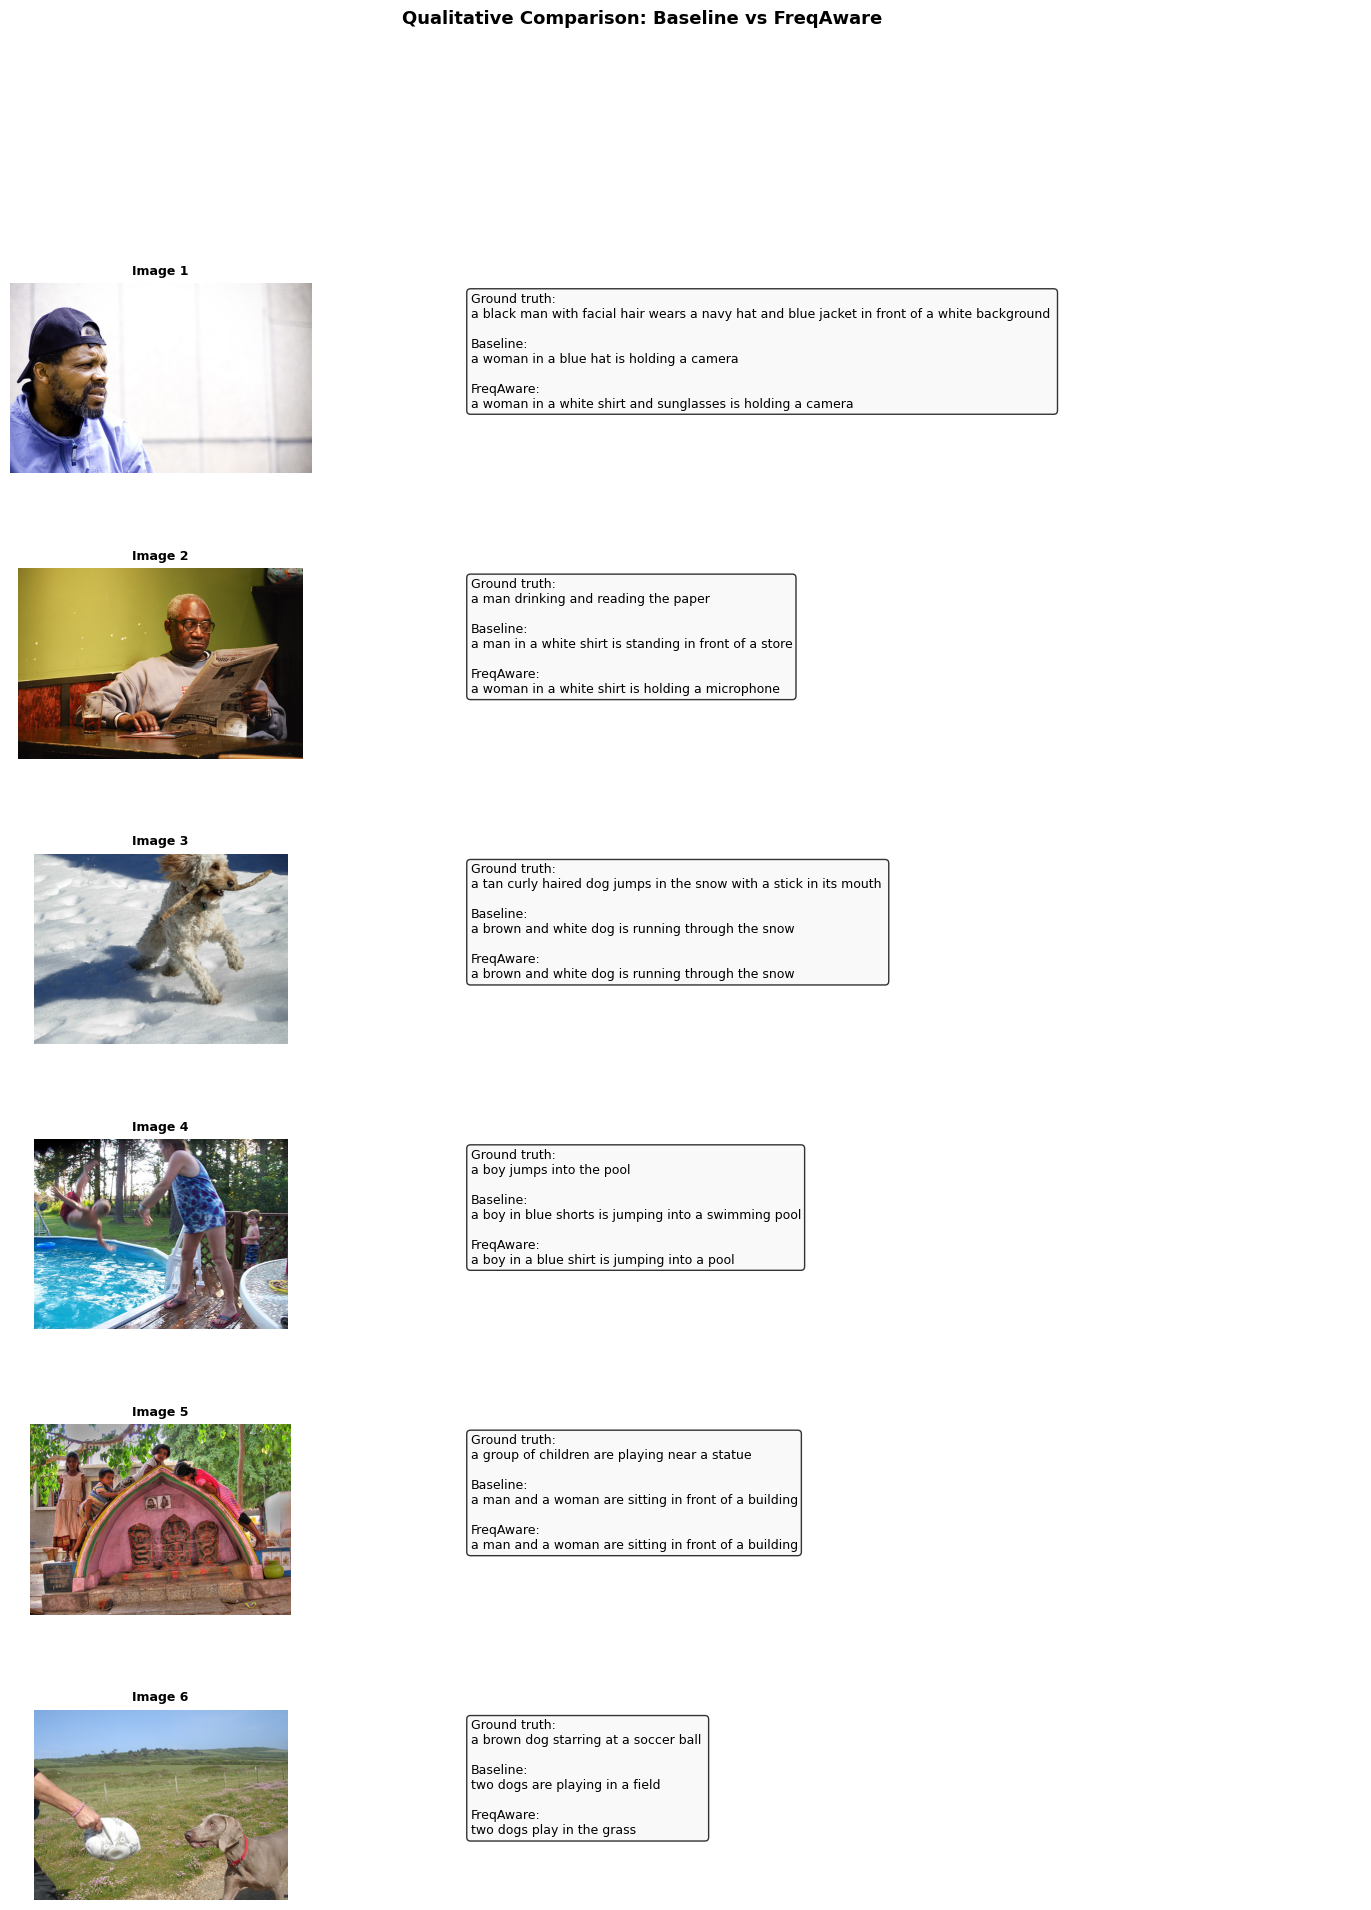

✅ Saved qualitative.png


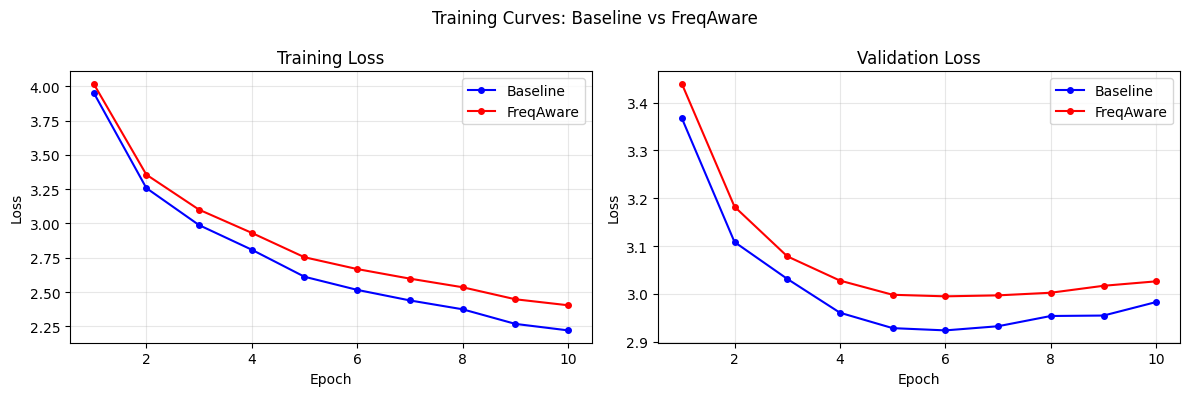

✅ Saved training_curves.png


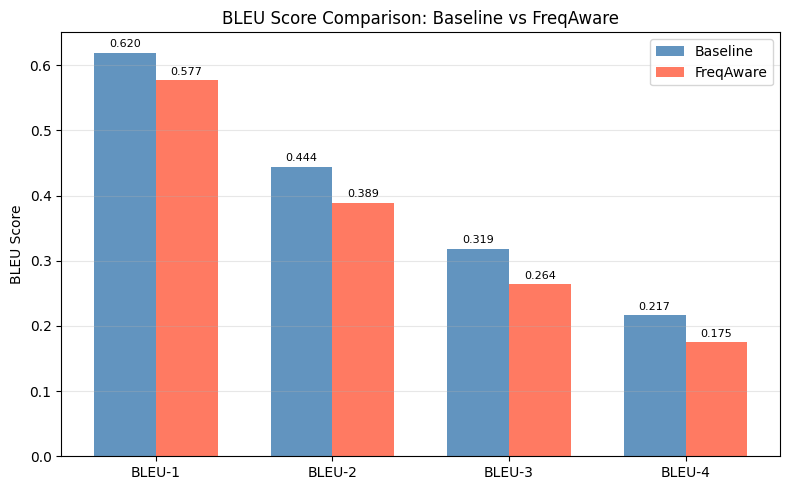

✅ Saved bleu_comparison.png

✅ Cell 11 done.


In [39]:
# ============================================================
# CELL 11 — Visualization & Qualitative Analysis
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import os
from PIL import Image

# --------------------------------------------------------
# Show sample captions for both models
# --------------------------------------------------------
def show_qualitative(n_samples=6, seed=42):
    random.seed(seed)
    sample_imgs = random.sample(list(val_df['image'].unique()), n_samples)

    fig = plt.figure(figsize=(18, n_samples * 3.5))
    gs  = gridspec.GridSpec(n_samples, 3, figure=fig,
                            wspace=0.3, hspace=0.5)

    for i, img_name in enumerate(sample_imgs):
        img_path = os.path.join(IMAGES_DIR, img_name)
        img_pil  = Image.open(img_path).convert('RGB')
        img_t    = val_transform(img_pil)

        cap_base = ' '.join(generate_caption(baseline_model,  img_t))
        cap_freq = ' '.join(generate_caption(freqaware_model, img_t))

        # Ground truth (first caption)
        gt = val_df[val_df['image'] == img_name]['caption'].iloc[0]

        # Image
        ax_img = fig.add_subplot(gs[i, 0])
        ax_img.imshow(img_pil)
        ax_img.axis('off')
        ax_img.set_title(f'Image {i+1}', fontsize=9, fontweight='bold')

        # Captions text
        ax_txt = fig.add_subplot(gs[i, 1:])
        ax_txt.axis('off')
        text = (f"Ground truth:\n{gt}\n\n"
                f"Baseline:\n{cap_base}\n\n"
                f"FreqAware:\n{cap_freq}")
        ax_txt.text(0, 0.95, text, transform=ax_txt.transAxes,
                    fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='#f8f8f8', alpha=0.8),
                    wrap=True)

    plt.suptitle('Qualitative Comparison: Baseline vs FreqAware',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(os.path.join(RESULTS_DIR, 'qualitative.png'),
                bbox_inches='tight', dpi=120)
    plt.show()
    print("✅ Saved qualitative.png")

# --------------------------------------------------------
# Plot training curves
# --------------------------------------------------------
def plot_training_curves():
    import json

    with open(os.path.join(RESULTS_DIR, 'baseline_history.json'))  as f:
        hist_b = json.load(f)
    with open(os.path.join(RESULTS_DIR, 'freqaware_history.json')) as f:
        hist_f = json.load(f)

    epochs = range(1, len(hist_b['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Train loss
    axes[0].plot(epochs, hist_b['train_loss'], 'b-o', label='Baseline',  markersize=4)
    axes[0].plot(epochs, hist_f['train_loss'], 'r-o', label='FreqAware', markersize=4)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Val loss
    axes[1].plot(epochs, hist_b['val_loss'], 'b-o', label='Baseline',  markersize=4)
    axes[1].plot(epochs, hist_f['val_loss'], 'r-o', label='FreqAware', markersize=4)
    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training Curves: Baseline vs FreqAware', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Saved training_curves.png")

# --------------------------------------------------------
# Plot BLEU comparison bar chart
# --------------------------------------------------------
def plot_bleu_comparison():
    labels  = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
    base_scores = [b1, b2, b3, b4]
    freq_scores = [f1, f2, f3, f4]

    x     = range(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar([i - width/2 for i in x], base_scores,
                   width, label='Baseline',  color='steelblue', alpha=0.85)
    bars2 = ax.bar([i + width/2 for i in x], freq_scores,
                   width, label='FreqAware', color='tomato',    alpha=0.85)

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylabel('BLEU Score')
    ax.set_title('BLEU Score Comparison: Baseline vs FreqAware')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    # Value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'bleu_comparison.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Saved bleu_comparison.png")

# --------------------------------------------------------
# Run all visualizations
# --------------------------------------------------------
show_qualitative(n_samples=6)
plot_training_curves()
plot_bleu_comparison()

print("\n✅ Cell 11 done.")

In [29]:
import subprocess, shutil

shutil.copy('/content/drive/MyDrive/Colab Notebooks/DLAI.ipynb', '/content/repo/DLAI.ipynb')
print("✅ Notebook copied")

cmds = [
    ['git', '-C', '/content/repo', 'add', '.'],
    ['git', '-C', '/content/repo', 'commit', '-m',
     'Add spatial cross-attention (v2): baseline BLEU-4 improved to 0.2006'],
    ['git', '-C', '/content/repo', 'push'],
]

for cmd in cmds:
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)

print("✅ Pushed to GitHub")

✅ Notebook copied

[main 44e3aec] Add spatial cross-attention (v2): baseline BLEU-4 improved to 0.2006
 1 file changed, 1 insertion(+), 1072 deletions(-)
 rewrite DLAI.ipynb (79%)


To https://github.com/zahrarezaei96/DLAI-FreqAware-Captioning.git
   85a97bc..44e3aec  main -> main

✅ Pushed to GitHub
